In [2]:

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sns.set_style("whitegrid")


In [4]:
df=pd.read_csv("SampleSuperstore.csv")

In [5]:
df

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [6]:
print("SHAPE:",df.shape)

SHAPE: (9994, 13)


In [7]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [49]:
print("Null values")
df.isnull().sum()

Null values


Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
ProfitMargin    0
dtype: int64

In [50]:
print("Duplicate Values")
df.duplicated().sum()

Duplicate Values


np.int64(0)

In [10]:
df=df.drop_duplicates()

In [11]:
df.shape

(9977, 13)

In [51]:
print("Descriptive Statistics")
df.describe()

Descriptive Statistics


,Postal Code,Sales,Quantity,Discount,Profit,ProfitMargin
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000,9977.000000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013,0.120114
std,32058.266816,623.721409,2.226657,0.206455,234.45784,0.466638
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800,-2.750000
25%,23223.000000,17.300000,2.000000,0.000000,1.72620,0.075000
50%,55901.000000,54.816000,3.000000,0.200000,8.67100,0.270000
75%,90008.000000,209.970000,5.000000,0.200000,29.37200,0.362500
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600,0.500000


In [ ]:
#Sales by Segment & Ship Mode

In [13]:
seg_sales=df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

In [15]:
ship_sales=df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)

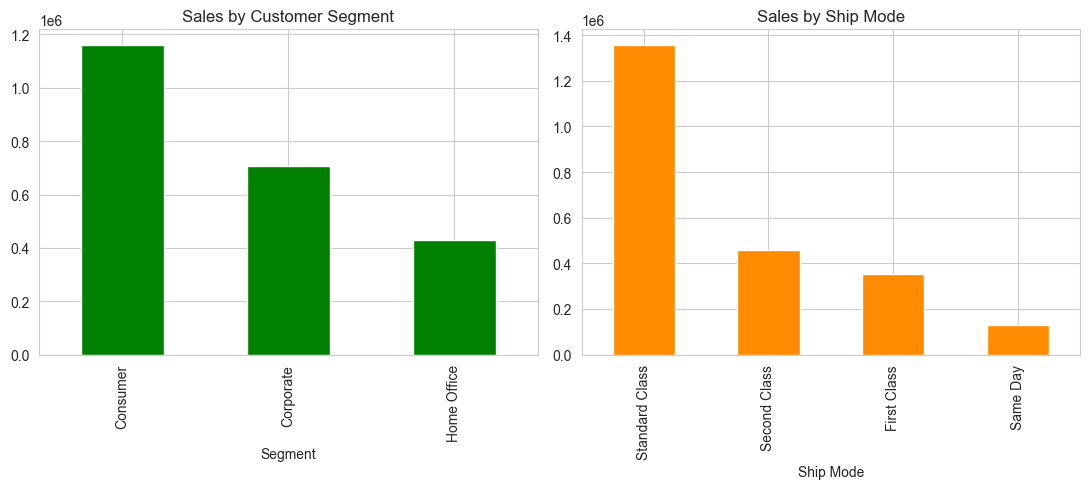

In [17]:
fig,axes= plt.subplots(1,2,figsize=(11,5))
seg_sales.plot(kind="bar",ax=axes[0],color="Green")
axes[0].set_title("Sales by Customer Segment")
ship_sales.plot(kind="bar",ax=axes[1],color="darkorange")
axes[1].set_title("Sales by Ship Mode")
plt.tight_layout()
fig.savefig("01_segment_shipmode_sales.pdf")
plt.show()

In [ ]:
#Observation: Consumer Segment drives the highest share of sales, Standard class shipping dominates. 

In [ ]:
#Sales by State and Region

In [18]:
top_states=df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

In [19]:
region_sales=df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

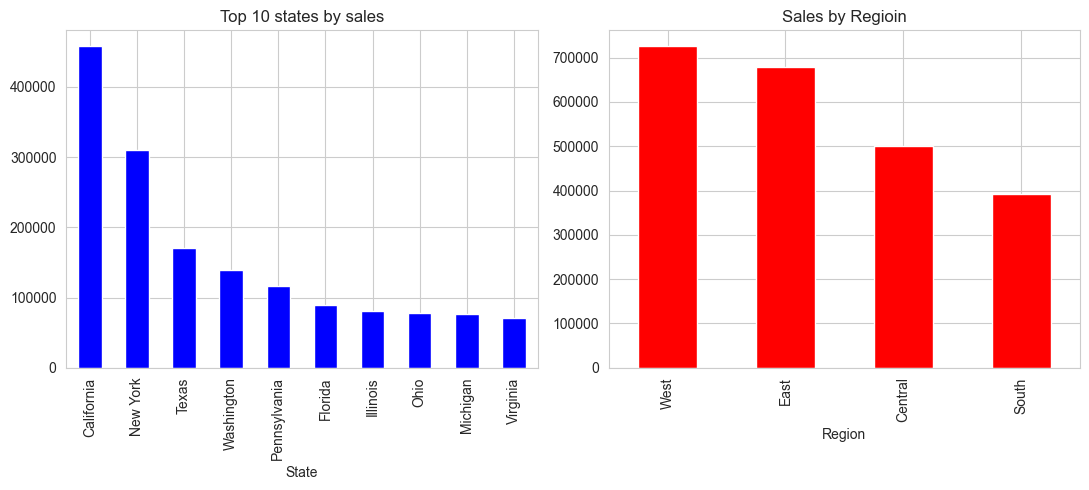

In [20]:
fig,axes= plt.subplots(1,2,figsize=(11,5))
top_states.plot(kind="bar",ax=axes[0],color="Blue")

axes[0].set_title("Top 10 states by sales")
region_sales.plot(kind="bar",ax=axes[1],color="Red")
axes[1].set_title("Sales by Regioin")
plt.tight_layout()
fig.savefig("02_state_region_sales.pdf")
plt.show()

In [ ]:
#Observation: sales concentrate heavily in  (California/New York/Texas), while the West and East regions out-earn central and south

In [ ]:
#Product Analysis

In [21]:
top_products=df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)

In [22]:
rev_by_category=df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

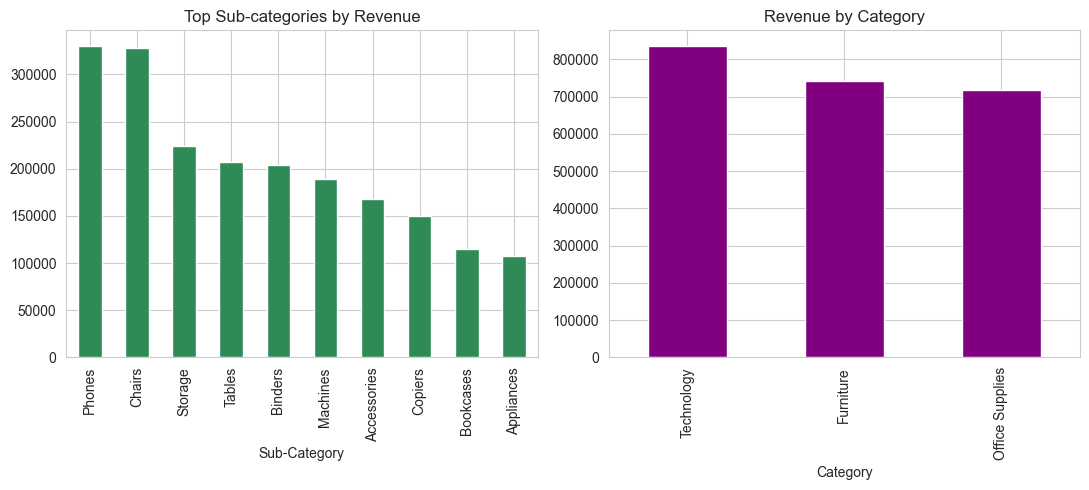

In [48]:
fig,axes= plt.subplots(1,2,figsize=(11,5))
top_products.plot(kind="bar",ax=axes[0],color="Seagreen")
axes[0].set_title("Top Sub-categories by Revenue")
rev_by_category.plot(kind="bar",ax=axes[1],color="Purple")
axes[1].set_title("Revenue by Category")
plt.tight_layout()
fig.savefig("03_product_analysis.pdf")
plt.show()

In [ ]:
#Observation: Technology and office supplies sub-categories (Phones, Chairs, Storage) dominates revenue

In [ ]:
#Correlation Heatmap

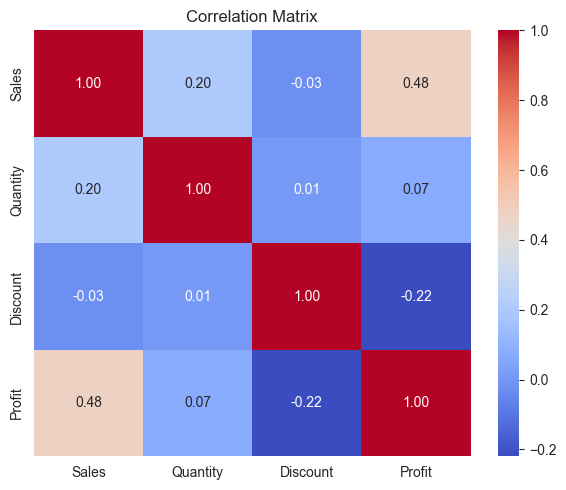

In [28]:
plt.figure(figsize=(6,5))
num_cols=["Sales","Quantity","Discount","Profit"]
sns.heatmap(df[num_cols].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("04_Correlation_heatmap.pdf")
plt.show()

In [ ]:
#Observation: Discount is negatively correlated with profit

In [ ]:
#profit margin by category & discount

In [30]:
df["ProfitMargin"]=df["Profit"]/df["Sales"].replace(0,np.nan)

C:\Users\mahja\AppData\Local\Temp\ipykernel_13080\175045934.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ProfitMargin"]=df["Profit"]/df["Sales"].replace(0,np.nan)


In [32]:
margin_by_cat_disc=df.groupby(["Category","Discount"])["ProfitMargin"].mean().unstack()

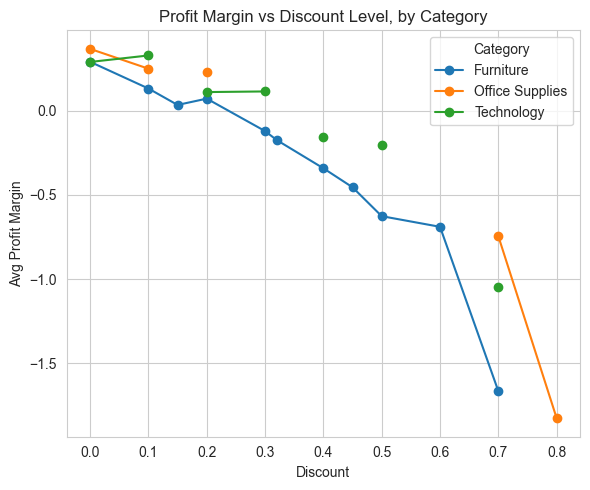

In [38]:
plt.figure(figsize=(6, 5))
margin_by_cat_disc.T.plot(marker="o",ax=plt.gca())
plt.title("Profit Margin vs Discount Level, by Category")
plt.xlabel("Discount")
plt.ylabel("Avg Profit Margin")
plt.tight_layout()
plt.savefig("05_margin_vs_discount.pdf")
plt.show()

In [46]:
worst_margin_cat = df.groupby("Category")["ProfitMargin"].mean().idxmin()
best_region = region_sales.idxmax()
top_subcat = top_products.idxmax()


In [47]:
print("BUSINESS RECOMMENDATIONS")
print(f"""
1. Give discounts on {worst_margin_cat} ; it has the lowest average profit margin ({df.groupby("Category")["ProfitMargin"].mean().min():.1%}).
2. Double down on the {best_region} region ; it generates the highest total sales; market can be shifted there. 
3. Make more promotions for  {top_subcat} as it is the  top revenue-generating sub-category.""")

BUSINESS RECOMMENDATIONS

1. Give discounts on Furniture ; it has the lowest average profit margin (3.9%).
2. Double down on the West region ; it generates the highest total sales; market can be shifted there. 
3. Make more promotions for  Phones as it is the  top revenue-generating sub-category.
